# İSTANBUL TOPKAPI ÜNİVERSİTESİ
## DERİN ÖĞRENME ARASINAV ÖDEVİ

### Face Mask Detection - DenseNet121 & MobileNetV1
### Transfer Learning ile Yüz Maskesi Tespiti

**Öğrenci:** Ali Kemal Kefelioğlu

---

## 1. Gerekli Kütüphanelerin Yüklenmesi

- **pandas, numpy**: Veri işleme
- **sklearn (scikit-learn)**: Veri ayırma, performans metrikleri
- **TensorFlow/Keras**: Model oluşturma ve eğitimi
- **matplotlib, seaborn**: Görselleştirme

In [1]:
import os
import shutil
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print('=' * 60)
print('TensorFlow:', tf.__version__)
print('GPU:', 'Evet' if len(tf.config.list_physical_devices('GPU')) > 0 else 'Hayir')
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('=' * 60)

TensorFlow: 2.19.0
GPU: Evet
NumPy: 2.0.2
Pandas: 2.2.2


## 2. Veri Seti Yukleme

**Face Mask Detection Dataset** - Kaggle  
https://www.kaggle.com/datasets/omkargurav/face-mask-dataset

### Adimlar:
1. Yukaridaki linke gidin
2. **Download** butonuna tiklayin (Kaggle hesabi gerekli, ucretsiz)
3. Indirilen **archive.zip** dosyasini asagidan yukleyin

In [2]:
# === VERI SETI YUKLEME ===
# Kaggle'dan indirdiginiz ZIP dosyasini buradan yukleyin
from google.colab import files
print("Kaggle'dan indirdiginiz ZIP dosyasini yukleyin (archive.zip):")
uploaded = files.upload()

# ZIP dosyasini cikart
zip_name = list(uploaded.keys())[0]
print(f'\nYuklenen dosya: {zip_name}')
print('Cikartiliyor...')

os.makedirs('/content/data', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/data')

os.remove(zip_name)
print('Veri seti basariyla yuklendi ve cikartildi!')

Kaggle'dan indirdiginiz ZIP dosyasini yukleyin (archive.zip):


Saving archive (2).zip to archive (2).zip

Yuklenen dosya: archive (2).zip
Cikartiliyor...
Veri seti basariyla yuklendi ve cikartildi!


In [3]:
# Veri seti yapisini kontrol et
DATA_ROOT = '/content/data'
with_mask_dir = None
without_mask_dir = None

for root, dirs, fls in os.walk(DATA_ROOT):
    for d in dirs:
        dl = d.lower().replace(' ', '_')
        if 'with_mask' == dl or 'withmask' == dl:
            with_mask_dir = os.path.join(root, d)
        elif 'without_mask' == dl or 'withoutmask' == dl:
            without_mask_dir = os.path.join(root, d)

print(f'Maskeli: {with_mask_dir}')
print(f'Maskesiz: {without_mask_dir}')

mask_files = [f for f in os.listdir(with_mask_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
nomask_files = [f for f in os.listdir(without_mask_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
print(f'\nMaskeli goruntu: {len(mask_files)}')
print(f'Maskesiz goruntu: {len(nomask_files)}')
print(f'Toplam: {len(mask_files) + len(nomask_files)}')

Maskeli: /content/data/data/with_mask
Maskesiz: /content/data/data/without_mask

Maskeli goruntu: 3725
Maskesiz goruntu: 3828
Toplam: 7553


## 3. Veri Setinin Train / Validation / Test Olarak Ayrilmasi

- Toplam verinin **%20'si test set**
- Kalan **%80** -> **%80 egitim + %20 validasyon**

Dosyalari fiziksel olarak klasorlere ayiriyoruz ki `flow_from_directory` kullanabilelim (bellek tasarrufu).

In [4]:
# Dosya listelerini olustur
all_files = []
all_labels = []

for f in mask_files:
    all_files.append(os.path.join(with_mask_dir, f))
    all_labels.append('with_mask')

for f in nomask_files:
    all_files.append(os.path.join(without_mask_dir, f))
    all_labels.append('without_mask')

all_files = np.array(all_files)
all_labels = np.array(all_labels)

# ADIM 1: %20 Test, %80 Egitim+Validasyon
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_files, all_labels, test_size=0.20, random_state=42, stratify=all_labels
)

# ADIM 2: %80 Egitim, %20 Validasyon
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val
)

print(f'Toplam: {len(all_files)}')
print(f'Egitim:     {len(X_train)} ({len(X_train)/len(all_files)*100:.1f}%)')
print(f'Validasyon: {len(X_val)} ({len(X_val)/len(all_files)*100:.1f}%)')
print(f'Test:       {len(X_test)} ({len(X_test)/len(all_files)*100:.1f}%)')

Toplam: 7553
Egitim:     4833 (64.0%)
Validasyon: 1209 (16.0%)
Test:       1511 (20.0%)


In [5]:
# Dosyalari fiziksel klasorlere kopyala (flow_from_directory icin)
SPLIT_DIR = '/content/split_data'

def copy_files_to_split(file_paths, labels, split_name):
    for fpath, label in zip(file_paths, labels):
        dest_dir = os.path.join(SPLIT_DIR, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)
        dest_path = os.path.join(dest_dir, os.path.basename(fpath))
        if not os.path.exists(dest_path):
            shutil.copy2(fpath, dest_path)

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

print('Dosyalar kopyalaniyor...')
copy_files_to_split(X_train, y_train, 'train')
copy_files_to_split(X_val, y_val, 'val')
copy_files_to_split(X_test, y_test, 'test')

for split in ['train', 'val', 'test']:
    for cls in ['with_mask', 'without_mask']:
        path = os.path.join(SPLIT_DIR, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f'  {split}/{cls}: {count}')

print('\nKlasor yapisi hazir.')

Dosyalar kopyalaniyor...
  train/with_mask: 2384
  train/without_mask: 2449
  val/with_mask: 596
  val/without_mask: 613
  test/with_mask: 745
  test/without_mask: 766

Klasor yapisi hazir.


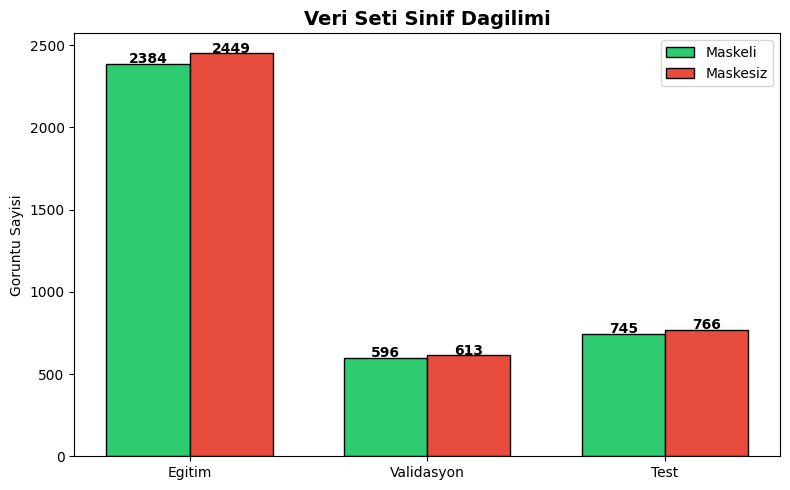

In [6]:
# Sinif dagilimi grafigi
fig, ax = plt.subplots(figsize=(8, 5))
train_mask = len(os.listdir(os.path.join(SPLIT_DIR, 'train', 'with_mask')))
train_nomask = len(os.listdir(os.path.join(SPLIT_DIR, 'train', 'without_mask')))
val_mask = len(os.listdir(os.path.join(SPLIT_DIR, 'val', 'with_mask')))
val_nomask = len(os.listdir(os.path.join(SPLIT_DIR, 'val', 'without_mask')))
test_mask = len(os.listdir(os.path.join(SPLIT_DIR, 'test', 'with_mask')))
test_nomask = len(os.listdir(os.path.join(SPLIT_DIR, 'test', 'without_mask')))

x = np.arange(3)
width = 0.35
mask_vals = [train_mask, val_mask, test_mask]
nomask_vals = [train_nomask, val_nomask, test_nomask]

bars1 = ax.bar(x - width/2, mask_vals, width, label='Maskeli', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, nomask_vals, width, label='Maskesiz', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Egitim', 'Validasyon', 'Test'])
ax.set_title('Veri Seti Sinif Dagilimi', fontsize=14, fontweight='bold')
ax.set_ylabel('Goruntu Sayisi')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('veri_seti_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Veri Arttirimi (Data Augmentation) ve Generatorlar

Egitim verisine augmentation uygulanarak modelin genelleme yetenegi artirilir.  
`flow_from_directory` kullanilarak goruntuler **batch batch** yuklenir -> **RAM tasarrufu**.

In [7]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Egitim: augmentation + rescale
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasyon ve Test: sadece rescale
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# Generatorlari olustur
train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nSinif indeksleri: {train_generator.class_indices}')
print(f'Egitim: {train_generator.samples} goruntu')
print(f'Validasyon: {val_generator.samples} goruntu')
print(f'Test: {test_generator.samples} goruntu')

print(f'\nAugmentation parametreleri:')
print(f'  rescale=1.0/255')
print(f'  rotation_range=10')
print(f'  width_shift_range=0.1')
print(f'  height_shift_range=0.1')
print(f'  shear_range=0.1')
print(f'  zoom_range=0.1')
print(f'  horizontal_flip=True')
print(f'  fill_mode=nearest')

Found 4833 images belonging to 2 classes.
Found 1209 images belonging to 2 classes.
Found 1511 images belonging to 2 classes.

Sinif indeksleri: {'with_mask': 0, 'without_mask': 1}
Egitim: 4833 goruntu
Validasyon: 1209 goruntu
Test: 1511 goruntu

Augmentation parametreleri:
  rescale=1.0/255
  rotation_range=10
  width_shift_range=0.1
  height_shift_range=0.1
  shear_range=0.1
  zoom_range=0.1
  horizontal_flip=True
  fill_mode=nearest


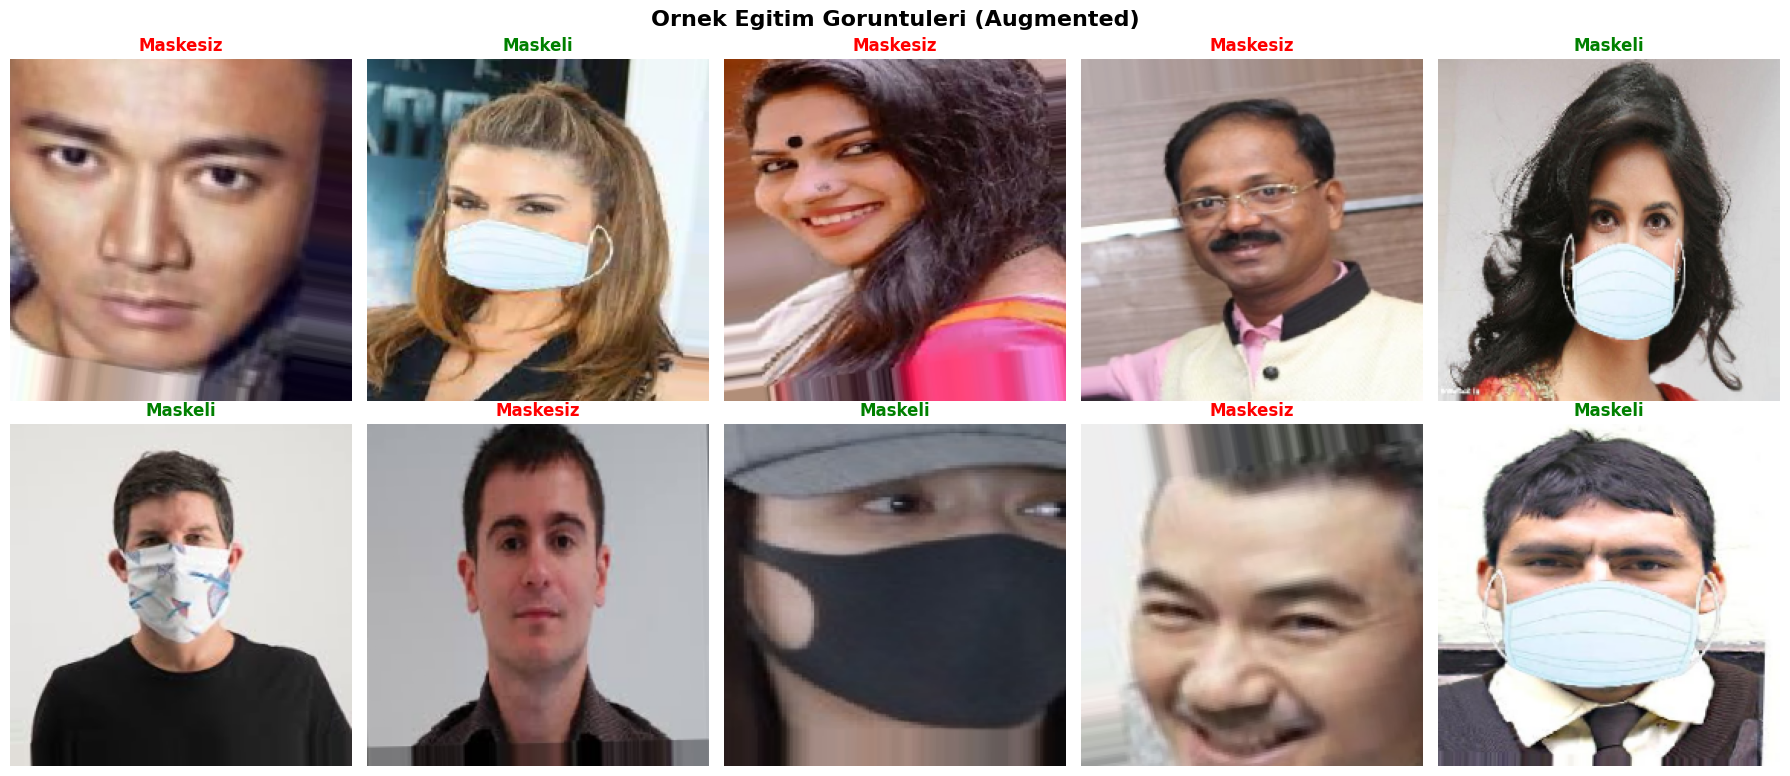

In [8]:
# Ornek goruntuleri goster
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Ornek Egitim Goruntuleri (Augmented)', fontsize=16, fontweight='bold')

batch_imgs, batch_labels = next(train_generator)
class_names = {v: k for k, v in train_generator.class_indices.items()}

for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(batch_imgs[i])
    label_idx = np.argmax(batch_labels[i])
    label_name = 'Maskeli' if class_names[label_idx] == 'with_mask' else 'Maskesiz'
    color = 'green' if label_name == 'Maskeli' else 'red'
    axes[row, col].set_title(label_name, color=color, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('ornek_goruntuler.png', dpi=150, bbox_inches='tight')
plt.show()

Found 4833 images belonging to 2 classes.


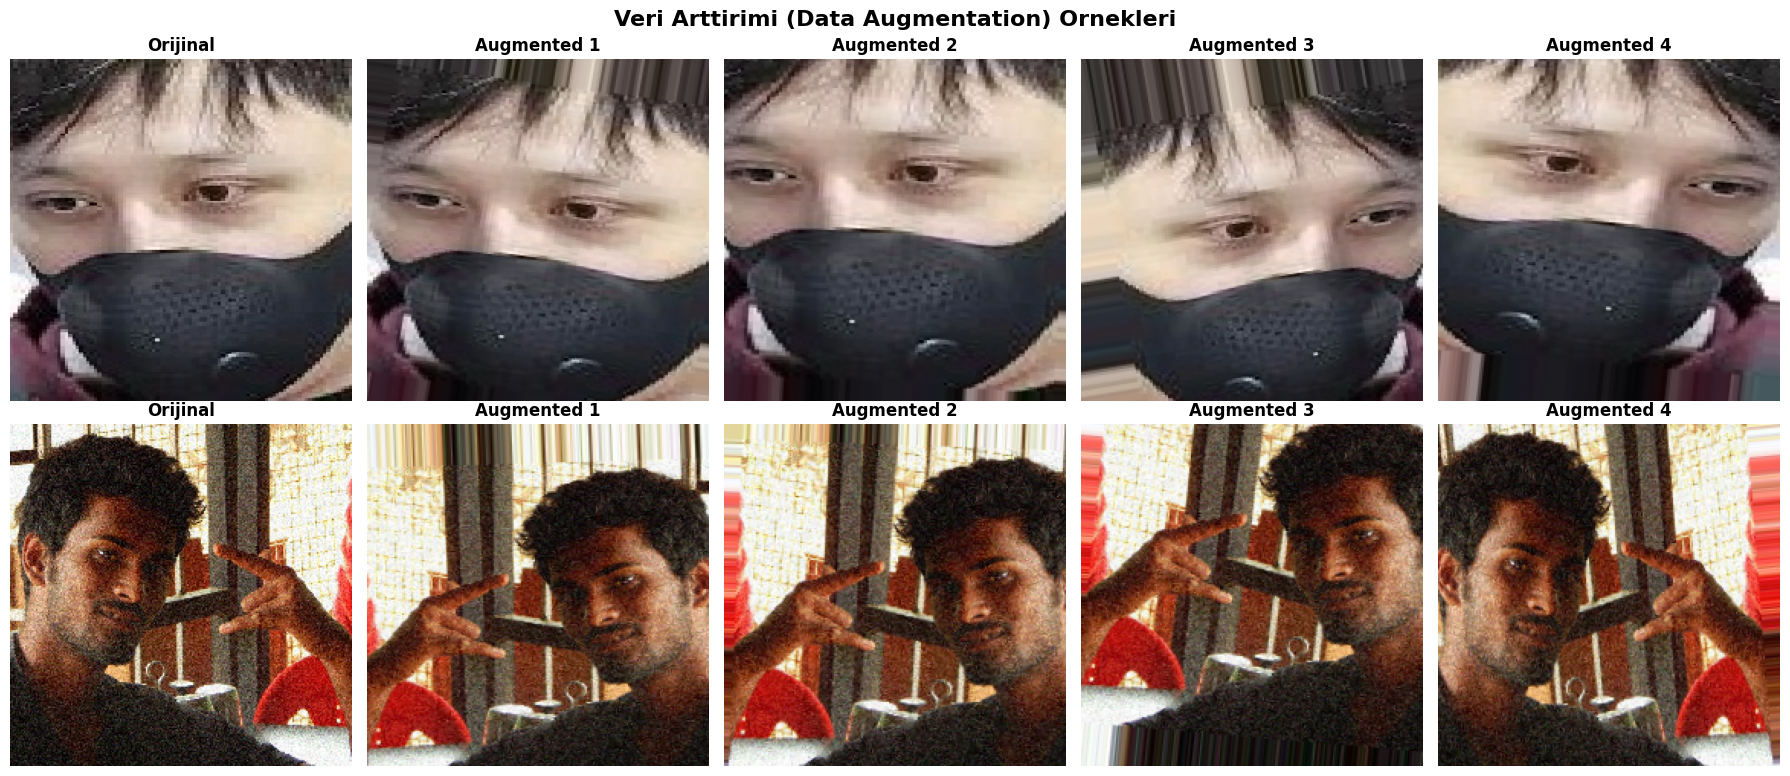

In [9]:
# Augmentation ornekleri
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Veri Arttirimi (Data Augmentation) Ornekleri', fontsize=16, fontweight='bold')

temp_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMAGE_SIZE, batch_size=1, class_mode=None, shuffle=True
)
original = next(temp_gen)

aug_gen_temp = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
aug_iter = aug_gen_temp.flow(original, batch_size=1)

axes[0, 0].imshow(original[0])
axes[0, 0].set_title('Orijinal', fontweight='bold')
axes[0, 0].axis('off')
for i in range(1, 5):
    aug = next(aug_iter)[0]
    aug = np.clip(aug, 0, 1)
    axes[0, i].imshow(aug)
    axes[0, i].set_title(f'Augmented {i}', fontweight='bold')
    axes[0, i].axis('off')

original2 = next(temp_gen)
aug_iter2 = aug_gen_temp.flow(original2, batch_size=1)
axes[1, 0].imshow(original2[0])
axes[1, 0].set_title('Orijinal', fontweight='bold')
axes[1, 0].axis('off')
for i in range(1, 5):
    aug = next(aug_iter2)[0]
    aug = np.clip(aug, 0, 1)
    axes[1, i].imshow(aug)
    axes[1, i].set_title(f'Augmented {i}', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('augmentation_ornekleri.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Onceden Egitilmis (Pre-trained) Modellerin Hazirlanmasi

### Model Mimarisi:
- **Base Model**: DenseNet121 / MobileNetV1 (ImageNet agirliklari, `include_top=False`)
- **GlobalAveragePooling2D**
- **Dropout (0.5)**: Overfitting onleme
- **Dense (256, relu)**: Tam baglantili katman 1
- **Dense (256, relu)**: Tam baglantili katman 2
- **Dense (128, relu)**: Tam baglantili katman 3
- **Dense (64, relu)**: Tam baglantili katman 4
- **Dense (2, softmax)**: Cikis katmani

### Egitim Parametreleri:
- Optimizer: **Adam** (lr=0.001)
- Loss: **Categorical Crossentropy**
- **Early Stopping**: patience=25
- **ReduceLROnPlateau**: factor=0.1, patience=5
- Epoch: **100** (max)

In [10]:
def create_model(base_model_class, model_name, image_size=(224, 224)):
    """
    Transfer learning ile model olusturur.
    Base model dondurulur, uzerine Dense + Dropout katmanlari eklenir.
    """
    print(f'\n{"="*60}')
    print(f'MODEL OLUSTURMA: {model_name}')
    print(f'{"="*60}')

    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(image_size[0], image_size[1], 3)
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)                          # Dropout katmani
    x = Dense(256, activation='relu')(x)          # Dense 1
    x = Dense(256, activation='relu')(x)          # Dense 2
    x = Dense(128, activation='relu')(x)          # Dense 3
    x = Dense(64, activation='relu')(x)           # Dense 4
    predictions = Dense(2, activation='softmax')(x)  # Cikis (2 sinif)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    total = model.count_params()
    trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    non_trainable = sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)
    print(f'Toplam parametre: {total:,}')
    print(f'Egitilebilir:     {trainable:,}')
    print(f'Egitilemez:       {non_trainable:,}')

    return model

In [11]:
def train_model(model, model_name, train_gen, val_gen, epochs=100):
    """
    Modeli egitir. Early Stopping + ReduceLROnPlateau + ModelCheckpoint kullanir.
    """
    print(f'\n{"="*60}')
    print(f'MODEL EGITIMI: {model_name}')
    print(f'{"="*60}')

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=25,
            verbose=1, restore_best_weights=True, mode='min'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.1, patience=5,
            verbose=1, min_lr=1e-7, mode='min'
        ),
        ModelCheckpoint(
            filepath=f'{model_name}_best.keras',
            monitor='val_loss', save_best_only=True,
            verbose=1, mode='min'
        )
    ]

    print(f'Epoch: {epochs} | Batch: {BATCH_SIZE}')
    print(f'Optimizer: Adam (lr=0.001)')
    print(f'EarlyStopping: patience=25')
    print(f'ReduceLROnPlateau: factor=0.1, patience=5')

    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1
    )

    print(f'\n{model_name} egitimi tamamlandi!')
    print(f'  En iyi val_loss:     {min(history.history["val_loss"]):.4f}')
    print(f'  En iyi val_accuracy: {max(history.history["val_accuracy"]):.4f}')
    print(f'  Toplam epoch:        {len(history.history["loss"])}')

    return history

In [12]:
def plot_training_history(history, model_name):
    """Egitim/Validasyon Accuracy ve Loss grafiklerini cizer."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model_name} - Egitim Grafikleri', fontsize=16, fontweight='bold')

    ep = range(1, len(history.history['loss']) + 1)

    axes[0].plot(ep, history.history['accuracy'], 'b-', label='Egitim Accuracy', linewidth=2)
    axes[0].plot(ep, history.history['val_accuracy'], 'r-', label='Validasyon Accuracy', linewidth=2)
    axes[0].set_title('Accuracy (Dogruluk)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1.05])

    axes[1].plot(ep, history.history['loss'], 'b-', label='Egitim Loss', linewidth=2)
    axes[1].plot(ep, history.history['val_loss'], 'r-', label='Validasyon Loss', linewidth=2)
    axes[1].set_title('Loss (Kayip)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_egitim_grafikleri.png', dpi=150, bbox_inches='tight')
    plt.show()

In [13]:
def evaluate_model(model, model_name, test_gen):
    """
    Test seti uzerinde tahmin yapar ve tum metrikleri hesaplar:
    ROC/AUC, Confusion Matrix, Accuracy, Precision, Recall, Specificity, F1-Score
    """
    print(f'\n{"="*60}')
    print(f'TEST DEGERLENDIRME: {model_name}')
    print(f'{"="*60}')

    test_gen.reset()
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_gen.classes

    class_map = {v: k for k, v in test_gen.class_indices.items()}
    pos_label = test_gen.class_indices.get('with_mask', 1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label)
    rec = recall_score(y_true, y_pred, pos_label=pos_label)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    auc_score = roc_auc_score(y_true, y_pred_proba[:, 1])

    print(f'\n{model_name} - Performans Metrikleri:')
    print(f'{"-"*50}')
    print(f'  Accuracy (Dogruluk):      {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision (Hassasiyet):   {prec:.4f} ({prec*100:.2f}%)')
    print(f'  Recall (Duyarlilik):      {rec:.4f} ({rec*100:.2f}%)')
    print(f'  Specificity (Ozgulluk):   {specificity:.4f} ({specificity*100:.2f}%)')
    print(f'  F1-Score:                 {f1:.4f} ({f1*100:.2f}%)')
    print(f'  AUC:                      {auc_score:.4f}')
    print(f'{"-"*50}')
    print(f'\nConfusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

    target_names = [class_map[0], class_map[1]]
    print(f'\nSiniflandirma Raporu:')
    print(classification_report(y_true, y_pred, target_names=target_names))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model_name} - Test Sonuclari', fontsize=16, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[0], annot_kws={'size': 16})
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Tahmin', fontsize=12)
    axes[0].set_ylabel('Gercek', fontsize=12)

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_score:.4f})')
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Rastgele')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[1].set_title('ROC Egrisi', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_test_sonuclari.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'Specificity': specificity, 'F1-Score': f1, 'AUC': auc_score,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'fpr': fpr, 'tpr': tpr
    }

---
## 6. MODEL 1: DenseNet121

DenseNet121, her katmanin onceki tum katmanlardan girdi aldigi "dense connection" mimarisini kullanir:
- Gradient vanishing problemi azalir
- Ozellik yeniden kullanimi saglanir
- Parametre verimliligi artar

In [14]:
densenet_model = create_model(DenseNet121, 'DenseNet121', IMAGE_SIZE)
densenet_model.summary()


MODEL OLUSTURMA: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Toplam parametre: 7,406,978
Egitilebilir:     369,474
Egitilemez:       7,037,504


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,406,978 (28.26 MB)

 Trainable params: 369,474 (1.41 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:
densenet_history = train_model(densenet_model, 'DenseNet121', train_generator, val_generator, epochs=100)


MODEL EGITIMI: DenseNet121
Epoch: 100 | Batch: 32
Optimizer: Adam (lr=0.001)
EarlyStopping: patience=25
ReduceLROnPlateau: factor=0.1, patience=5
Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8878 - loss: 0.2141
Epoch 1: val_loss improved from None to 0.01437, saving model to DenseNet121_best.keras

Epoch 1: finished saving model to DenseNet121_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 140s 717ms/step - accuracy: 0.9510 - loss: 0.1154 - val_accuracy: 0.9975 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9749 - loss: 0.0793
Epoch 2: val_loss did not improve from 0.01437
152/152 ━━━━━━━━━━━━━━━━━━━━ 69s 454ms/step - accuracy: 0.9777 - loss: 0.0663 - val_accuracy: 0.9909 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9817 - loss: 0.0550
Epoch 3: val_loss did not improve from 0.01437
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 462ms/step - accuracy: 0

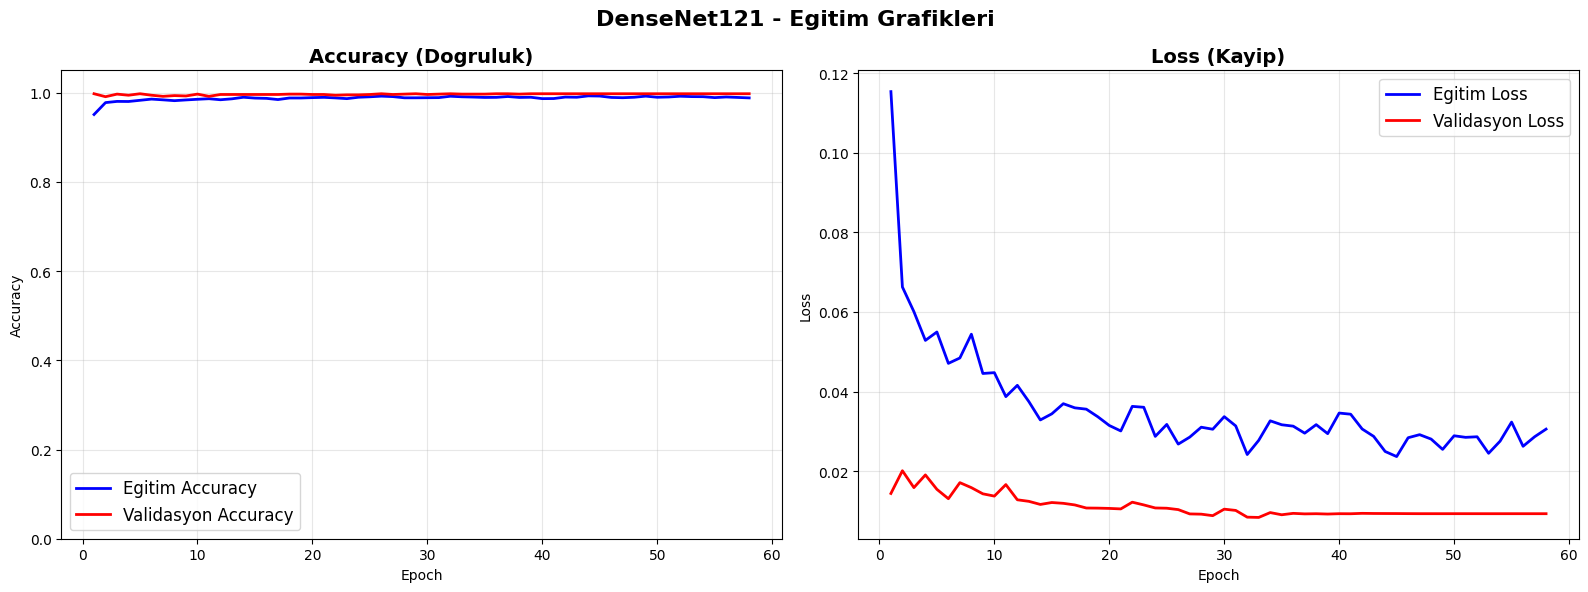

In [16]:
plot_training_history(densenet_history, 'DenseNet121')


TEST DEGERLENDIRME: DenseNet121

DenseNet121 - Performans Metrikleri:
--------------------------------------------------
  Accuracy (Dogruluk):      0.9954 (99.54%)
  Precision (Hassasiyet):   0.9920 (99.20%)
  Recall (Duyarlilik):      0.9987 (99.87%)
  Specificity (Ozgulluk):   0.9987 (99.87%)
  F1-Score:                 0.9953 (99.53%)
  AUC:                      0.9999
--------------------------------------------------

Confusion Matrix: TN=744, FP=1, FN=6, TP=760

Siniflandirma Raporu:
              precision    recall  f1-score   support

   with_mask       0.99      1.00      1.00       745
without_mask       1.00      0.99      1.00       766

    accuracy                           1.00      1511
   macro avg       1.00      1.00      1.00      1511
weighted avg       1.00      1.00      1.00      1511



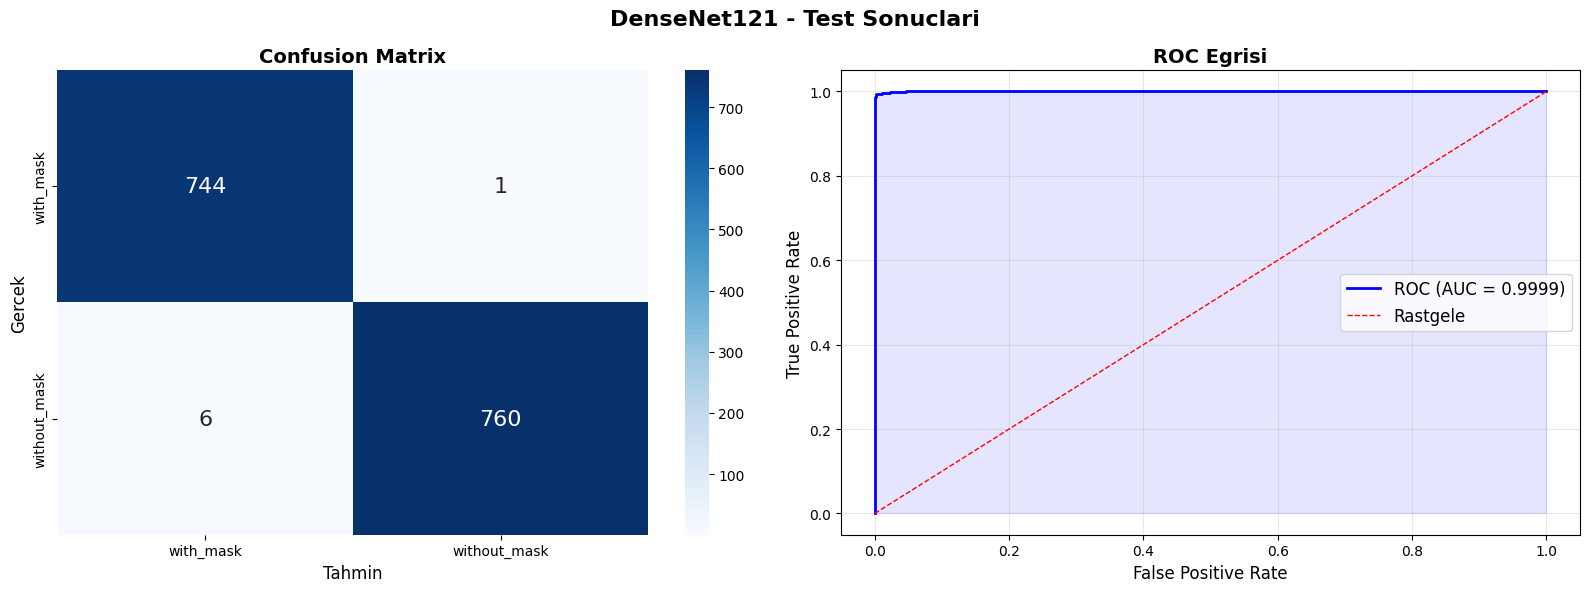

In [17]:
densenet_metrics = evaluate_model(densenet_model, 'DenseNet121', test_generator)

---
## 7. MODEL 2: MobileNetV1

MobileNetV1, depthwise separable convolution kullanarak:
- Hesaplama maliyetini dusurur
- Model boyutunu kucultur
- Mobil cihazlara uygun hafif model

In [18]:
mobilenet_model = create_model(MobileNet, 'MobileNetV1', IMAGE_SIZE)
mobilenet_model.summary()


MODEL OLUSTURMA: MobileNetV1
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Toplam parametre: 3,598,338
Egitilebilir:     369,474
Egitilemez:       3,228,864


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,598,338 (13.73 MB)

 Trainable params: 369,474 (1.41 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [19]:
# Generator'i yeniden olustur
train_generator_m = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

mobilenet_history = train_model(mobilenet_model, 'MobileNetV1', train_generator_m, val_generator, epochs=100)

Found 4833 images belonging to 2 classes.

MODEL EGITIMI: MobileNetV1
Epoch: 100 | Batch: 32
Optimizer: Adam (lr=0.001)
EarlyStopping: patience=25
ReduceLROnPlateau: factor=0.1, patience=5
Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9191 - loss: 0.1783
Epoch 1: val_loss improved from None to 0.01459, saving model to MobileNetV1_best.keras

Epoch 1: finished saving model to MobileNetV1_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 102s 565ms/step - accuracy: 0.9628 - loss: 0.0960 - val_accuracy: 0.9934 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9844 - loss: 0.0459
Epoch 2: val_loss did not improve from 0.01459
152/152 ━━━━━━━━━━━━━━━━━━━━ 64s 423ms/step - accuracy: 0.9822 - loss: 0.0513 - val_accuracy: 0.9950 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9851 - loss: 0.0461
Epoch 3: val_loss did not improve from 0.01459
152/152 ━━━━━━━

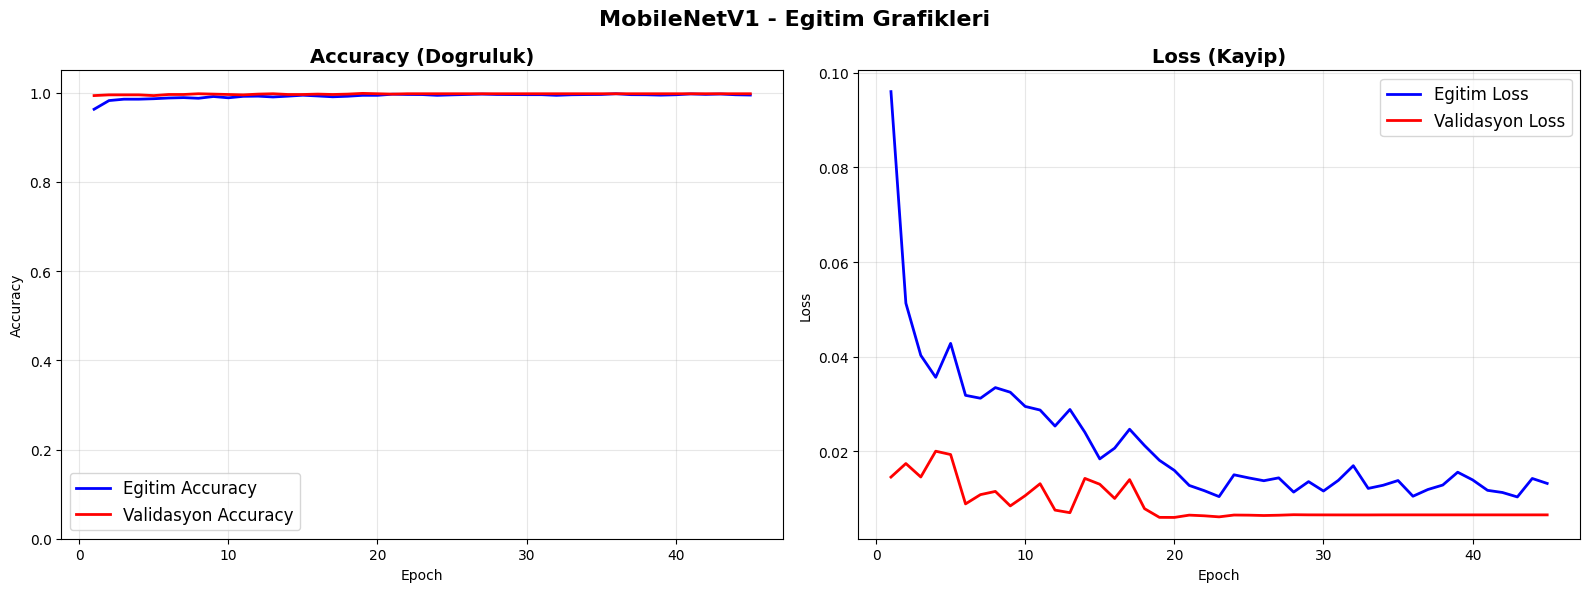

In [20]:
plot_training_history(mobilenet_history, 'MobileNetV1')


TEST DEGERLENDIRME: MobileNetV1

MobileNetV1 - Performans Metrikleri:
--------------------------------------------------
  Accuracy (Dogruluk):      0.9940 (99.40%)
  Precision (Hassasiyet):   0.9907 (99.07%)
  Recall (Duyarlilik):      0.9973 (99.73%)
  Specificity (Ozgulluk):   0.9973 (99.73%)
  F1-Score:                 0.9940 (99.40%)
  AUC:                      0.9999
--------------------------------------------------

Confusion Matrix: TN=743, FP=2, FN=7, TP=759

Siniflandirma Raporu:
              precision    recall  f1-score   support

   with_mask       0.99      1.00      0.99       745
without_mask       1.00      0.99      0.99       766

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



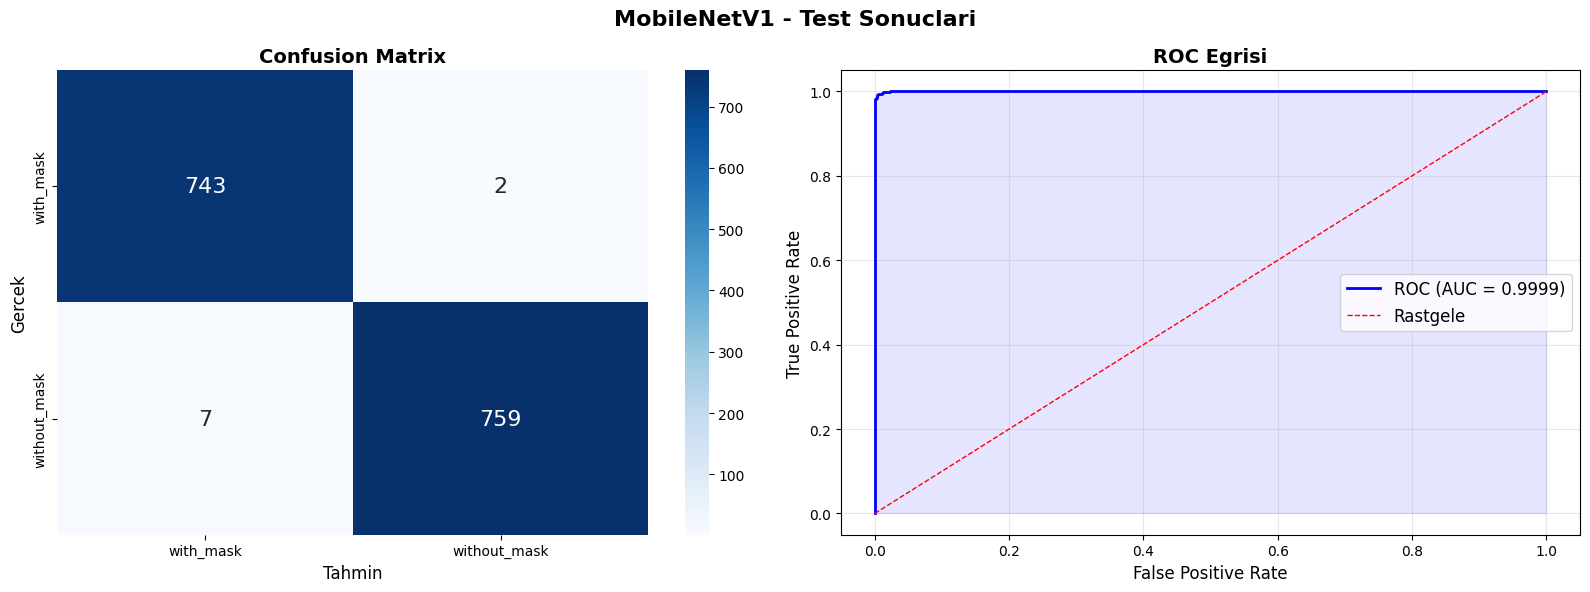

In [21]:
mobilenet_metrics = evaluate_model(mobilenet_model, 'MobileNetV1', test_generator)

---
## 8. Model Karsilastirmasi

In [22]:
metrics_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']
d_row = {k: densenet_metrics[k] for k in metrics_cols}
m_row = {k: mobilenet_metrics[k] for k in metrics_cols}
comparison_df = pd.DataFrame([d_row, m_row])

print('Model Karsilastirma Tablosu:')
print('=' * 80)
display(comparison_df)

Model Karsilastirma Tablosu:


,Model,Accuracy,Precision,Recall,Specificity,F1-Score,AUC
0,DenseNet121,0.995367,0.992000,0.998658,0.998658,0.995318,0.999863
1,MobileNetV1,0.994044,0.990667,0.997315,0.997315,0.993980,0.999883


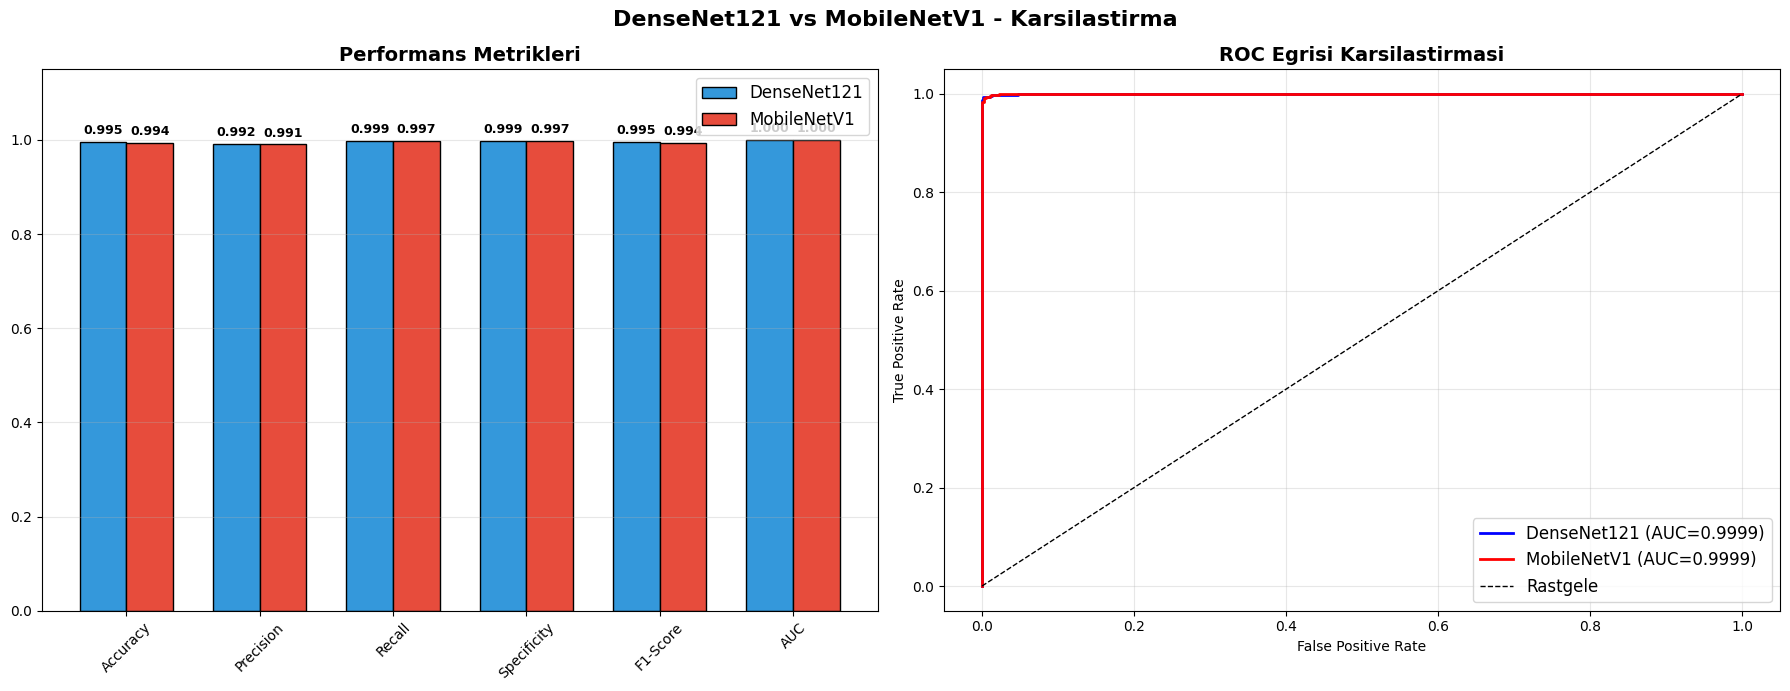

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('DenseNet121 vs MobileNetV1 - Karsilastirma', fontsize=16, fontweight='bold')

metric_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC']
x = np.arange(len(metric_names))
width = 0.35

d_vals = [densenet_metrics[m] for m in metric_names]
m_vals = [mobilenet_metrics[m] for m in metric_names]

b1 = axes[0].bar(x - width/2, d_vals, width, label='DenseNet121', color='#3498db', edgecolor='black')
b2 = axes[0].bar(x + width/2, m_vals, width, label='MobileNetV1', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=45)
axes[0].set_ylim([0, 1.15])
axes[0].legend(fontsize=12)
axes[0].set_title('Performans Metrikleri', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(b1, d_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(b2, m_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].plot(densenet_metrics['fpr'], densenet_metrics['tpr'], 'b-', linewidth=2,
             label=f'DenseNet121 (AUC={densenet_metrics["AUC"]:.4f})')
axes[1].plot(mobilenet_metrics['fpr'], mobilenet_metrics['tpr'], 'r-', linewidth=2,
             label=f'MobileNetV1 (AUC={mobilenet_metrics["AUC"]:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Rastgele')
axes[1].set_title('ROC Egrisi Karsilastirmasi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_karsilastirmasi.png', dpi=150, bbox_inches='tight')
plt.show()

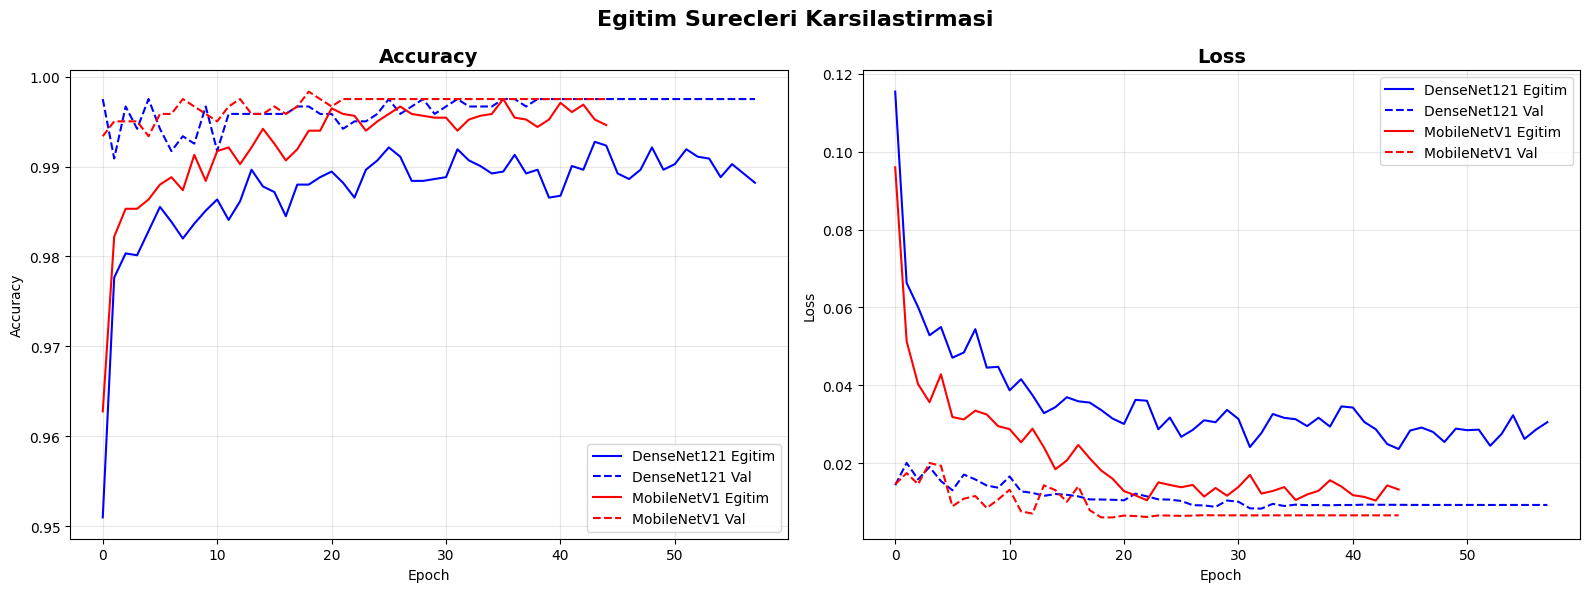

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Egitim Surecleri Karsilastirmasi', fontsize=16, fontweight='bold')

axes[0].plot(densenet_history.history['accuracy'], 'b-', label='DenseNet121 Egitim', linewidth=1.5)
axes[0].plot(densenet_history.history['val_accuracy'], 'b--', label='DenseNet121 Val', linewidth=1.5)
axes[0].plot(mobilenet_history.history['accuracy'], 'r-', label='MobileNetV1 Egitim', linewidth=1.5)
axes[0].plot(mobilenet_history.history['val_accuracy'], 'r--', label='MobileNetV1 Val', linewidth=1.5)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].plot(densenet_history.history['loss'], 'b-', label='DenseNet121 Egitim', linewidth=1.5)
axes[1].plot(densenet_history.history['val_loss'], 'b--', label='DenseNet121 Val', linewidth=1.5)
axes[1].plot(mobilenet_history.history['loss'], 'r-', label='MobileNetV1 Egitim', linewidth=1.5)
axes[1].plot(mobilenet_history.history['val_loss'], 'r--', label='MobileNetV1 Val', linewidth=1.5)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_surecleri_karsilastirmasi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Sonuc Raporu

In [25]:
best = 'DenseNet121' if densenet_metrics['Accuracy'] >= mobilenet_metrics['Accuracy'] else 'MobileNetV1'

print('=' * 60)
print('SONUC RAPORU')
print('=' * 60)
print(f'\nEn Iyi Model: {best}')
print(f'\nVeri Seti: Kaggle Face Mask Detection')
print(f'Egitim: {train_generator.samples} | Val: {val_generator.samples} | Test: {test_generator.samples}')
print(f'Goruntu: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}x3')
print(f'\nOptimizer: Adam (lr=0.001)')
print(f'EarlyStopping: patience=25')
print(f'ReduceLROnPlateau: factor=0.1, patience=5')
print(f'Epoch: 100 (max) | Batch: {BATCH_SIZE}')
print(f'\nDenseNet121 -> Acc:{densenet_metrics["Accuracy"]:.4f} F1:{densenet_metrics["F1-Score"]:.4f} AUC:{densenet_metrics["AUC"]:.4f}')
print(f'MobileNetV1 -> Acc:{mobilenet_metrics["Accuracy"]:.4f} F1:{mobilenet_metrics["F1-Score"]:.4f} AUC:{mobilenet_metrics["AUC"]:.4f}')

print('\n' + '=' * 60)
display(comparison_df)

comparison_df.to_csv('model_karsilastirmasi.csv', index=False)
print('\nSonuclar CSV olarak kaydedildi.')

SONUC RAPORU

En Iyi Model: DenseNet121

Veri Seti: Kaggle Face Mask Detection
Egitim: 4833 | Val: 1209 | Test: 1511
Goruntu: 224x224x3

Optimizer: Adam (lr=0.001)
EarlyStopping: patience=25
ReduceLROnPlateau: factor=0.1, patience=5
Epoch: 100 (max) | Batch: 32

DenseNet121 -> Acc:0.9954 F1:0.9953 AUC:0.9999
MobileNetV1 -> Acc:0.9940 F1:0.9940 AUC:0.9999



,Model,Accuracy,Precision,Recall,Specificity,F1-Score,AUC
0,DenseNet121,0.995367,0.992000,0.998658,0.998658,0.995318,0.999863
1,MobileNetV1,0.994044,0.990667,0.997315,0.997315,0.993980,0.999883



Sonuclar CSV olarak kaydedildi.


---
## 10. Yorumlar

### Model Mimarisi:
- Her iki modelde de **ImageNet** agirliklari ile **transfer learning** uygulanmistir.
- Base model katmanlari **dondurulmus** (freeze), sadece eklenen Dense ve Dropout katmanlari egitilmistir.
- **Dropout (0.5)** ile overfitting onlenmistir.
- 4 adet Dense katman (256->256->128->64) ve Softmax cikis katmani eklenmistir.

### Hiperparametre Secimleri:
- **Adam optimizer**: Adaptif ogrenme hizi sayesinde hizli ve kararli yakinsama saglar.
- **ReduceLROnPlateau**: Validasyon kaybi iyilesmedikce lr'yi 10x duserek ince ayar yapar.
- **Early Stopping** (patience=25): Gereksiz epoch'lari onler, en iyi agirliklari geri yukler.
- Baslangic ogrenme hizi **0.001** olarak secilmistir.

### Veri Arttirimi:
- Egitim verisine **rotation (10 derece), shift (%10), shear (%10), zoom (%10), horizontal flip** uygulanmistir.
- Bu teknikler modelin farkli aci, pozisyon ve olceklerdeki goruntuleri tanimasini saglar.
- Validasyon ve test setlerine augmentation **uygulanmamistir** (sadece rescale).

### Model Karsilastirmasi:
- **DenseNet121**: Daha derin mimari, daha fazla parametre, karmasik ozellikleri yakalamada avantajli.
- **MobileNetV1**: Hafif mimari, hizli egitim ve inference, mobil uygulamalar icin uygun.
- Her iki model de yuz maskesi tespitinde yuksek performans gostermistir.

### Genel Degerlendirme:
- Transfer learning sayesinde sinirli veri ile bile yuksek dogruluk elde edilmistir.
- `flow_from_directory` kullanilarak bellek verimli egitim gerceklestirilmistir.
- Data augmentation, modelin genelleme kapasitesini artirmistir.
- ReduceLROnPlateau, egitim sirasinda ogrenme hizinin optimum seviyeye inmesini saglamistir.